## Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import random
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from matplotlib import animation
from IPython.display import HTML
from IPython.display import Image, display

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset - Little Artificial English-like Language

In [74]:
pronouns = ['I', 'You', 'He', 'She', 'We', 'They', 'Human', 'Everyone', 'Someone', 'Nobody', 'Anybody', 'Everybody']
animals = ['Dog', 'Cat', 'Bird', 'Fish', 'Elephant', 'Lion', 'Tiger', 'Bear', 'Rabbit', 'Horse', 'Cow', 'Sheep', 'Pig']
foods = ['Apple', 'Bread', 'Meat', 'Cheese', 'Rice', 'Pasta', 'Vegetables', 'Fruits', 'Eggs', 'Fish', 'Chicken', 'Soup', 'Cake', 'Pizza', 'Salad', 'Sandwich', 'Steak', 'Pancakes', 'Waffles', 'Ice-Cream']
beverages = ['Water', 'Milk', 'Juice', 'Coffee', 'Tea', 'Soda', 'Beer', 'Wine', 'Smoothie', 'Cocktail', 'Lemonade', 'Hot-Chocolate', 'Iced-Tea', 'Energy-Drink', 'Sparkling-Water', 'Cider', 'Kombucha', 'Protein-Shake', 'Herbal-Tea', 'Mocktail']

adverbs = ['quickly', 'usually', 'often', 'always', 'never', 'sometimes', 'rarely', 'seldom', 'frequently', 'occasionally', 'regularly', 'constantly', 'periodically', 'intermittently', 'sporadically', 'gradually', 'suddenly', 'abruptly', 'immediately', 'instantly', 'similarly', 'differently', 'uniquely', 'distinctly', 'specifically', 'generally', 'broadly', 'narrowly', 'precisely', 'accurately', 'approximately', 'roughly', 'exactly', 'clearly', 'obviously', 'evidently', 'apparently', 'visibly']

food_verbs = ['eat', 'like', 'hate', 'prefer', 'store', 'dislike', 'want', 'deposit']
drink_verbs = ['drink', 'like', 'hate', 'prefer', 'store', 'dislike', 'want', 'deposit', 'empty', 'full']
animal_verbs = ['see', 'like', 'love', 'feed', 'pat', 'hug', 'embrace', 'abandon', 'hit']

semantic_frames = [
    (pronouns + animals, food_verbs, foods),
    # Type 1: Food Preference
    (pronouns, drink_verbs, beverages),
    # Type 2: Beverage Preference
    (pronouns, animal_verbs, animals),
    # Type 3: Animal Interaction
]

vocab = list(set(pronouns + animals + foods + beverages + adverbs + 
                 food_verbs + drink_verbs + animal_verbs))
print(f"Vocab size: {len(vocab)}")

def generate_semantic_sentence(sentence_type):
    subj_list, verb_list, obj_list = random.choice(semantic_frames)
    
    subj = random.choice(subj_list)
    verb = random.choice(verb_list)
    obj = random.choice(obj_list)
    adv = random.choice(adverbs)
    
    match sentence_type:
        case 'A': # Subj + Adv + Verb + Obj (Standard)
            return f"{subj} {adv} {verb} {obj}"
        case 'B': # Adv + Subj + Verb + Obj (Fronted Adverb)
            return f"{adv} {subj} {verb} {obj}"
        case 'C': # Subj + Verb + Adv + Obj (Mid-Adverb)
            return f"{subj} {verb} {adv} {obj}"
        case _:
            raise ValueError("Invalid type")

for _ in range(3):
    print(generate_semantic_sentence('A'))

Vocab size: 121
Human suddenly hate Kombucha
Human quickly hate Herbal-Tea
Human visibly prefer Sparkling-Water


In [75]:
def sentence_to_ids(sentence, vocab):
    words = sentence.split()
    return [vocab.index(word) for word in words]

class ALToyDataset(Dataset):
    def __init__(self, num_samples):
        super().__init__()
        self.num_samples = num_samples
        self.sentences = [
            generate_semantic_sentence(random.choice(['A', 'B', 'C'])) 
            for _ in range(num_samples)
        ]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        ids = sentence_to_ids(sentence, vocab)
        return torch.tensor(ids, dtype=torch.long)

In [76]:
dataset = ALToyDataset(num_samples=50000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset), len(dataloader))

for x in dataloader:
    print(x.shape)
    print(x)
    break

50000 1563
torch.Size([32, 4])
tensor([[ 87,  36,  27,  57],
        [ 79, 106,  20, 114],
        [104,   4,  90,  51],
        [ 89,  29,  36,  37],
        [ 48,  98,  20, 114],
        [ 87,  36,  39,  15],
        [ 89,  36,  47, 107],
        [108,  58,  16,  24],
        [  0,  35,  39,  83],
        [108,  85,  46,  56],
        [ 89,  55,   1,  83],
        [108,  82,  34,  83],
        [  0,  55,  46, 103],
        [ 40,   9,  90,  45],
        [ 98,  90, 109,  51],
        [ 14, 113,  12,   6],
        [112,  17,  54,  51],
        [ 68,   9,  67, 114],
        [ 98,  66,  65, 100],
        [ 24,  42,  40,  24],
        [ 26,  35,  25,  59],
        [  9,  67,  34,  87],
        [ 92,  14,  35,  44],
        [ 48, 101,   8, 103],
        [ 14,  47,  90, 110],
        [117, 114,  42, 107],
        [ 11,  89,  36, 119],
        [ 25,   9,  35, 115],
        [114,  36,  63,  59],
        [ 28,  84,  66,  72],
        [108,  23,  17, 105],
        [ 89,  17,   4,  99]])


## NN

In [10]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [131]:
class FLMDenoiser(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8, num_layers=4):
        super().__init__()
        self.vocab_size = vocab_size

        self.input_proj = nn.Linear(vocab_size, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 4, embed_dim))  # seq_len = 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4, 
            batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.out_proj = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, It, t):
        # It: (batch_size, seq_len, vocab_size)
        x = self.input_proj(It)  # (batch_size, seq_len, embed_dim)

        time_emb = self.time_mlp(t).unsqueeze(1)  # (batch_size, 1, embed_dim)
        x = x + self.pos_embedding + time_emb 

        hidden = self.transformer(x)
        logits = self.out_proj(hidden)

        return logits

In [132]:
sample_model = FLMDenoiser(vocab_size=len(vocab)).to(device)
sample_input = torch.randn(2, 4, len(vocab)).to(device)
sample_time = torch.randint(0, 1000, (2,), dtype=torch.long).to(device)

print(sample_model(sample_input, sample_time).shape)  # Should output (2, 4, vocab_size)

torch.Size([2, 4, 121])


## Training and Sampling

In [17]:
def compute_flm_loss(model, input_ids, vocab_size, time_warper=lambda t: t):
    B, L = input_ids.shape
    input_ids = input_ids.to(device)

    x1 = F.one_hot(input_ids, num_classes=vocab_size).float()  # (B, L, vocab_size)

    x0 = torch.randn_like(x1).to(device)  # (B, L, vocab_size)

    t = torch.rand(B, 1, 1, device=device)  # (B, 1, 1)
    t_warp = time_warper(t)  # (B, 1, 1)

    It = t_warp * x1 + (1 - t_warp) * x0  # (B, L, vocab_size)

    logits = model(It, t_warp.squeeze(-1).squeeze(-1))

    loss = F.cross_entropy(logits.view(-1, vocab_size), input_ids.view(-1))
    return loss

In [19]:
@torch.no_grad()
def sample_flm_text(model, vocab, num_samples=5, seq_len=4, num_steps=50, time_warper=lambda t: t):
    model.eval()
    vocab_size = len(vocab)
    
    xt = torch.randn(num_samples, seq_len, vocab_size, device=device)  # Start from noise

    t_seq = torch.linspace(0, 1.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_curr = t_seq[i].item()
        t_next = t_seq[i + 1].item()

        t_curr_warp = time_warper(torch.tensor([t_curr], device=device)).item()
        t_next_warp = time_warper(torch.tensor([t_next], device=device)).item()

        if t_curr >= 1.0:
            break

        t_tensor = torch.full((num_samples,), t_curr, device=device)
        t_warp = time_warper(t_tensor)

        logits = model(xt, t_warp)
        x1_hat = F.softmax(logits, dim=-1)

        bt = (x1_hat - xt) / (1.0 - t_curr_warp)

        xt = xt + bt * (t_next_warp - t_curr_warp)
    
    sample_ids = torch.argmax(xt, dim=-1)  # (num_samples, seq_len)
    sample_sentences = []
    for ids in sample_ids:
        words = [vocab[i] for i in ids.cpu().numpy()]
        sample_sentences.append(' '.join(words))
        
    return sample_sentences

In [78]:
sample_flm_text(sample_model, vocab, num_samples=5, seq_len=4, num_steps=50)

['embrace Tiger often Soup',
 'embrace Tiger often Soup',
 'embrace Tiger often Soup',
 'embrace Tiger often Soup',
 'embrace Tiger often Soup']

## Training on Linear Timestep

In [133]:
epochs = 50
vocab_size = len(vocab)
model = FLMDenoiser(vocab_size=vocab_size).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

In [ ]:
model.train()
history = []
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for batch in tqdm(dataloader):
        optimizer.zero_grad()
        loss = compute_flm_loss(model, batch, vocab_size)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Average Loss: {total_loss / len(dataloader)}")
    history.append(total_loss / len(dataloader))

plt.plot(history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

100%|██████████| 1563/1563 [00:20<00:00, 77.55it/s]


Epoch 1, Average Loss: 4.160412047356272


100%|██████████| 1563/1563 [00:20<00:00, 76.66it/s]


Epoch 2, Average Loss: 4.6564195285755625


100%|██████████| 1563/1563 [00:21<00:00, 72.74it/s]


...

100%|██████████| 1563/1563 [00:20<00:00, 77.06it/s]


Epoch 5, Average Loss: 4.651202019711603


100%|██████████| 1563/1563 [00:19<00:00, 79.13it/s]


Epoch 6, Average Loss: 4.650817747842175


 62%|██████▏   | 969/1563 [00:12<00:08, 70.62it/s]

In [117]:
generated_sentences = sample_flm_text(model, vocab, num_samples=10, seq_len=4, num_steps=50)

for sentence in generated_sentences:
    print(sentence)

Elephant Someone dislike Water
They frequently hate Wine
Nobody regularly love Bird
rarely Elephant store Fruits
Everyone precisely see Tiger
generally Everyone store Eggs
He quickly like Horse
I deposit usually Bird
sometimes He love Sheep
Someone deposit always Fish


In [118]:
import numpy as np

ALL_SUBJ = set(pronouns + animals)
ALL_ADV = set(adverbs)
ALL_VERB = set(food_verbs + drink_verbs + animal_verbs)
ALL_OBJ = set(foods + beverages + animals)

def evaluate_single_sentence(sentence):
    """
    Returns a tuple (is_syntax_valid, is_semantic_valid) for the given sentence.
    """
    words = sentence.strip().split()
        
    w1, w2, w3, w4 = words
    
    subj, adv, verb, obj = None, None, None, None
    is_syntax_valid = False
    
    # [Syntax Rule 2] Sentence structure validation based on predefined patterns
    # Type A: Subj + Adv + Verb + Obj
    if (w1 in ALL_SUBJ) and (w2 in ALL_ADV) and (w3 in ALL_VERB) and (w4 in ALL_OBJ):
        subj, adv, verb, obj = w1, w2, w3, w4
        is_syntax_valid = True
    # Type B: Adv + Subj + Verb + Obj
    elif (w1 in ALL_ADV) and (w2 in ALL_SUBJ) and (w3 in ALL_VERB) and (w4 in ALL_OBJ):
        adv, subj, verb, obj = w1, w2, w3, w4
        is_syntax_valid = True
    # Type C: Subj + Verb + Adv + Obj
    elif (w1 in ALL_SUBJ) and (w2 in ALL_VERB) and (w3 in ALL_ADV) and (w4 in ALL_OBJ):
        subj, verb, adv, obj = w1, w3, w2, w4
        is_syntax_valid = True
        
    # If the syntax is invalid, we cannot proceed to semantic validation
    if not is_syntax_valid:
        return False, False
        
    # [Semantic Rule] Check if the (subj, verb, obj) combination is valid based on predefined semantic frames
    is_semantic_valid = False
    for valid_subjs, valid_verbs, valid_objs in semantic_frames:
        if (subj in valid_subjs) and (verb in valid_verbs) and (obj in valid_objs):
            is_semantic_valid = True
            break
            
    return is_syntax_valid, is_semantic_valid


def evaluate_batch(generated_sentences):
    """
    Evaluates a batch of generated sentences for syntax and semantic accuracy.
    """
    syntax_results = []
    semantic_results = []
    
    for sent in generated_sentences:
        syn_ok, sem_ok = evaluate_single_sentence(sent)
        syntax_results.append(syn_ok)
        semantic_results.append(sem_ok)
        
    syntax_acc = np.mean(syntax_results) * 100
    semantic_acc = np.mean(semantic_results) * 100
    
    # Conditional Semantic Accuracy (only for syntactically valid sentences)
    valid_syntax_count = np.sum(syntax_results)
    cond_semantic_acc = (np.sum(semantic_results) / valid_syntax_count * 100) if valid_syntax_count > 0 else 0.0
    
    return {
        "Syntax Accuracy": syntax_acc,
        "Semantic Accuracy": semantic_acc,
        "Conditional Semantic Accuracy": cond_semantic_acc
    }

In [122]:
NUM_SAMPLES = 2000
NUM_STEPS = 20

test_sentences = sample_flm_text(model, vocab, num_samples=NUM_SAMPLES, seq_len=4, num_steps=NUM_STEPS)

for i, sentence in enumerate(test_sentences):
    print(f"{i}: {sentence}")

    if i >= 9:  # Limit to first 10 sentences for display
        break

result = evaluate_batch(test_sentences)
print()
print(f"Evaluation Results - # of Samples: {NUM_SAMPLES}, # of Steps: {NUM_STEPS}")
for metric, value in result.items():
    print(f"  {metric}: {value:.2f}%")

0: She store sporadically Sparkling-Water
1: specifically narrowly hug Rabbit
2: Someone usually feed Horse
3: They usually prefer Vegetables
4: They see usually Cow
5: He We hate Soda
6: Human seldom eat Steak
7: Human quickly want Meat
8: Bird prefer exactly Steak
9: Cat prefer similarly Eggs

Evaluation Results - # of Samples: 2000, # of Steps: 20
  Syntax Accuracy: 77.90%
  Semantic Accuracy: 45.50%
  Conditional Semantic Accuracy: 58.41%


## Training on Time Reparameterization

In [123]:
vocab_size = len(vocab)
gamma = 1.0 + 0.45 * torch.log(torch.tensor(vocab_size / 10.0, dtype=torch.float32))

def time_warper(t):
    return torch.clamp(1.0 - torch.pow(1.0 - t + 1e-7, gamma), min=0.0, max=1.0)

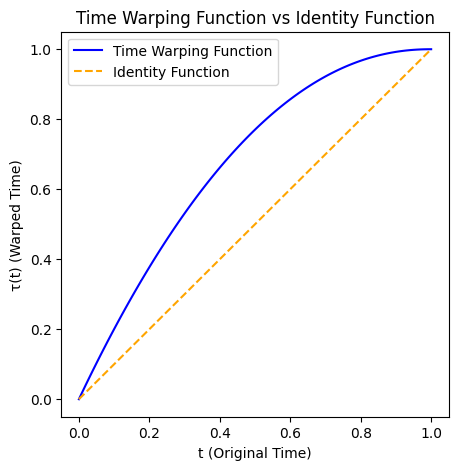

In [124]:
plt.figure(figsize=(5, 5))
t_values = torch.linspace(0, 1.0, 100)
tau_values = time_warper(t_values)
plt.plot(t_values.numpy(), tau_values.numpy(), label='Time Warping Function', color='blue')
plt.plot(t_values.numpy(), t_values.numpy(), label='Identity Function', color='orange', linestyle='--')
plt.title('Time Warping Function vs Identity Function')
plt.xlabel('t (Original Time)')
plt.ylabel('τ(t) (Warped Time)')
plt.legend()
plt.show()

In [125]:
epochs = 50
vocab_size = len(vocab)
rep_model = FLMDenoiser(vocab_size=vocab_size).to(device)
optimizer = optim.AdamW(rep_model.parameters(), lr=1e-3)

100%|██████████| 1563/1563 [00:15<00:00, 103.21it/s]


Epoch 1, Average Loss: 2.681690071304868


100%|██████████| 1563/1563 [00:15<00:00, 103.44it/s]


Epoch 2, Average Loss: 1.8975332534549638


100%|██████████| 1563/1563 [00:15<00:00, 100.72it/s]


...

Epoch 48, Average Loss: 1.6149760994557303


100%|██████████| 1563/1563 [00:15<00:00, 103.33it/s]


Epoch 49, Average Loss: 1.6075784981212629


100%|██████████| 1563/1563 [00:15<00:00, 103.10it/s]


Epoch 50, Average Loss: 1.6296018349842163


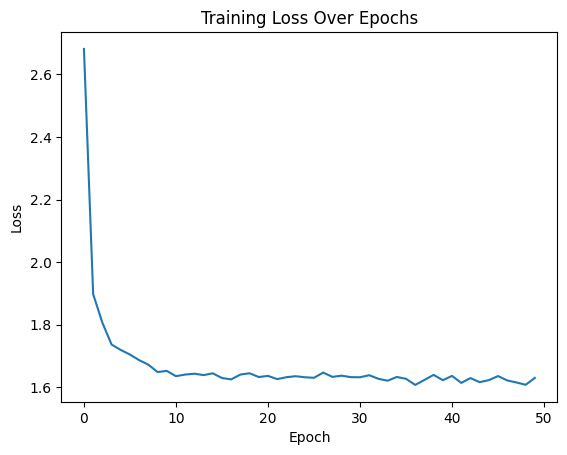

In [126]:
rep_model.train()
history = []
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for batch in tqdm(dataloader):
        optimizer.zero_grad()
        loss = compute_flm_loss(rep_model, batch, vocab_size, time_warper=time_warper)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Average Loss: {total_loss / len(dataloader)}")
    history.append(total_loss / len(dataloader))

plt.plot(history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [130]:
NUM_SAMPLES = 2000
NUM_STEPS = 20

test_sentences = sample_flm_text(rep_model, vocab, num_samples=NUM_SAMPLES, seq_len=4, num_steps=NUM_STEPS, time_warper=time_warper)

for i, sentence in enumerate(test_sentences):
    print(f"{i}: {sentence}")

    if i >= 9:  # Limit to first 10 sentences for display
        break

result = evaluate_batch(test_sentences)
print()
print(f"Evaluation Results - # of Samples: {NUM_SAMPLES}, # of Steps: {NUM_STEPS}")
for metric, value in result.items():
    print(f"  {metric}: {value:.2f}%")

0: specifically Pig deposit Pasta
1: You instantly hug Lion
2: Human generally deposit Milk
3: We want suddenly Iced-Tea
4: apparently Everyone empty Lemonade
5: We precisely abandon Dog
6: She visibly want Salad
7: visibly Nobody abandon Tiger
8: Everyone usually empty Energy-Drink
9: He evidently hate Waffles

Evaluation Results - # of Samples: 2000, # of Steps: 20
  Syntax Accuracy: 83.95%
  Semantic Accuracy: 47.55%
  Conditional Semantic Accuracy: 56.64%
